# 03 · Baseline models (Phase 7)

Five models evaluated with the validation design fixed in notebook 02 — 5 × repeated 5-fold `StratifiedGroupKFold`
grouped by chamber atmosphere (25 test folds), on the **primary** dataset (252 FLEX tests, 80 sustained).

**All numbers are produced by `scripts/train_baselines.py`** and read here from `reports/phase7/`. These are
*cross-validated predictions*, not experimental results; hyperparameters are fixed a priori (no tuning yet — Phase 8).

| Model | Inputs | Notes |
|---|---|---|
| Majority baseline | none | predicts the training sustained rate |
| O₂-only logistic | x_o2 | the obvious baseline to beat |
| Logistic regression | 6 inputs + fuel × d₀ | L2, C = 1 |
| Random forest | 6 inputs | 500 trees, min_samples_leaf = 3 |
| XGBoost | 6 inputs | depth 3, 300 rounds, lr 0.05, O₂ monotone-increasing |

The decision threshold for the "safe" operating point is picked by an inner grouped CV on each training fold
(largest threshold reaching recall ≥ 0.90 on sustained), then applied unchanged to the test fold.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import display
from flameguard import eda, plots

eda.use_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
R = ROOT / "reports" / "phase7"
folds = pd.read_csv(R / "fold_metrics.csv")
oof = pd.read_csv(R / "oof_predictions.csv")
pooled = pd.read_csv(R / "pooled_metrics.csv")
leak = pd.read_csv(R / "leakage_check.csv")
print(json.dumps(json.loads((R / "run_info.json").read_text()), indent=1))

{
 "data": {
  "variant": "primary",
  "tests": 252,
  "sustained": 80,
  "extinguished": 172,
  "groups": 44,
  "excluded": {
   "missing_d0": 12,
   "out_of_scope_pressure_2-3atm": 9,
   "missing_pressure": 1
  }
 },
 "cv": {
  "scheme": "StratifiedGroupKFold",
  "group": "group_id_atmosphere",
  "n_splits": 5,
  "n_repeats": 5,
  "seed": 0
 },
 "threshold_rule": "largest threshold with inner grouped-CV recall >= 0.90 on the training fold",
 "versions": {
  "python": "3.12.10",
  "sklearn": "1.9.1",
  "xgboost": "3.4.1",
  "pandas": "3.0.6",
  "numpy": "2.5.3"
 }
}


## 1. Threshold-free metrics (mean ± sd over 25 test folds)

In [2]:
summary = pd.read_csv(R / "summary.csv", index_col=0)
summary[["roc_auc", "pr_auc", "brier", "log_loss"]]

,roc_auc,pr_auc,brier,log_loss
model,,,,
majority_baseline,0.500 ± 0.000,0.313 ± 0.032,0.216 ± 0.012,0.623 ± 0.026
o2_only_logreg,0.821 ± 0.055,0.699 ± 0.106,0.152 ± 0.039,0.469 ± 0.102
logreg,0.922 ± 0.050,0.868 ± 0.087,0.109 ± 0.034,0.346 ± 0.112
random_forest,0.878 ± 0.065,0.808 ± 0.107,0.134 ± 0.034,0.414 ± 0.084
xgboost,0.886 ± 0.059,0.802 ± 0.117,0.136 ± 0.041,0.418 ± 0.114


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


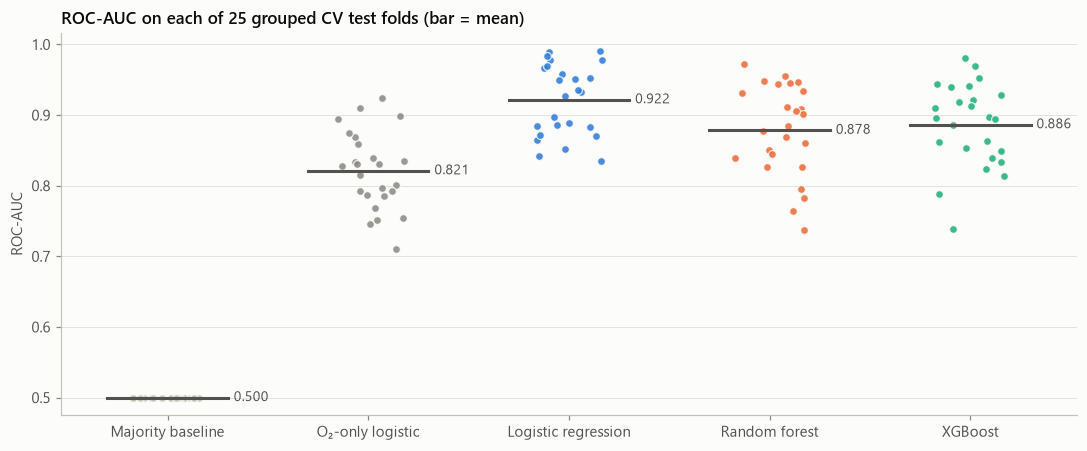

In [3]:
fig = plots.plot_fold_metric(folds, "roc_auc", "ROC-AUC")
_ = eda.save(fig, "07_fold_roc_auc")

**Read-out.**
- Every model beats the majority baseline, and every multi-input model beats O₂ alone — the other inputs (fuel,
  droplet size, suppressant, pressure) add real information beyond oxygen.
- **Logistic regression is the best model** on every threshold-free metric (ROC-AUC 0.922 ± 0.050, PR-AUC 0.868,
  Brier 0.109). The tree models are close to each other (≈ 0.88) and both behind it.
- Fold-to-fold spread is large (sd ≈ 0.05–0.07): with 44–69 tests per fold, a single split could easily mislead.

### Is the logistic regression lead consistent? (paired by split)

In [4]:
wide = folds.pivot(index="split", columns="model", values="roc_auc")
rows = []
for m in ["o2_only_logreg", "random_forest", "xgboost"]:
    d = wide["logreg"] - wide[m]
    rows.append({"comparison": f"logreg − {m}", "mean ΔROC-AUC": round(d.mean(), 3), "sd": round(d.std(), 3),
                 "logreg better": f"{(d > 0).sum()}/25", "ties": int((d == 0).sum())})
pd.DataFrame(rows)

,comparison,mean ΔROC-AUC,sd,logreg better,ties
0,logreg − o2_only_logreg,0.101,0.045,25/25,0
1,logreg − random_forest,0.043,0.035,24/25,0
2,logreg − xgboost,0.035,0.036,22/25,1


Logistic regression wins in 24/25 splits against random forest and 22/25 against XGBoost. The splits share
training data, so this is evidence of consistency, not a formal significance test.

A plausible reason (not proven here): with 252 tests, a smooth boundary in O₂ with a fuel-dependent droplet-size
term — exactly what the logistic model encodes — is easier to estimate than the step-shaped boundaries trees build.
Phase 8 checks whether tuning closes the gap.

## 2. Curves (pooled out-of-fold, one CV repeat)

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


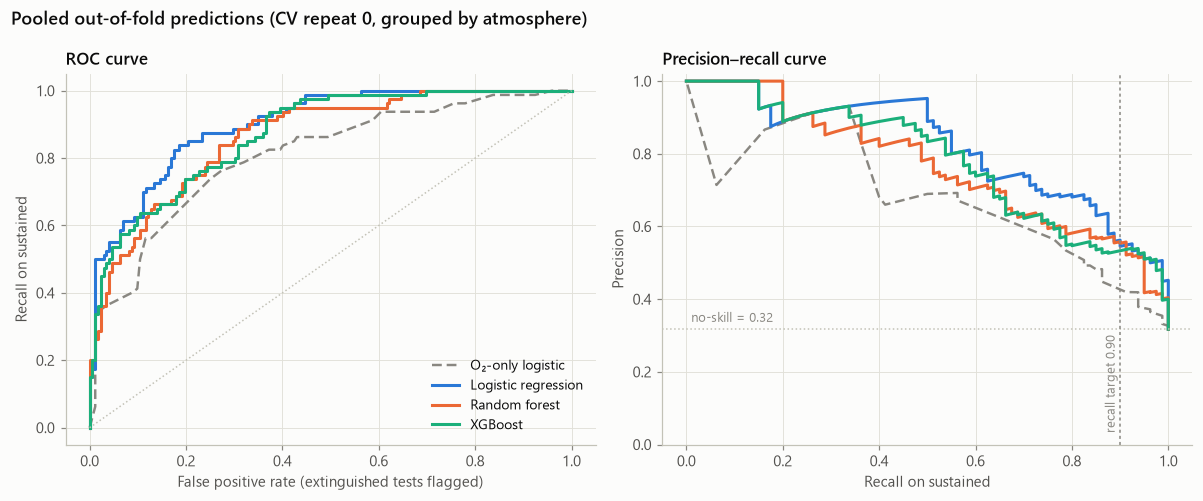

In [5]:
fig = plots.plot_curves(oof, repeat=0)
_ = eda.save(fig, "08_roc_pr_curves")

## 3. Safety view — missed fires

A **false negative** is a test that kept burning but was predicted to self-extinguish. At the default 0.5
threshold, every model misses a third or more of sustained tests:

In [6]:
summary[["accuracy@0.5", "recall@0.5", "precision@0.5", "false_negative_rate@0.5"]]

,accuracy@0.5,recall@0.5,precision@0.5,false_negative_rate@0.5
model,,,,
majority_baseline,0.687 ± 0.032,0.000 ± 0.000,0.000 ± 0.000,1.000 ± 0.000
o2_only_logreg,0.778 ± 0.086,0.534 ± 0.209,0.761 ± 0.258,0.466 ± 0.209
logreg,0.840 ± 0.050,0.658 ± 0.140,0.830 ± 0.127,0.342 ± 0.140
random_forest,0.798 ± 0.074,0.571 ± 0.220,0.802 ± 0.171,0.429 ± 0.220
xgboost,0.812 ± 0.062,0.668 ± 0.138,0.762 ± 0.162,0.332 ± 0.138


That is unacceptable for a fire-safety tool, which is why the evaluation plan fixed a recall-targeted
threshold chosen inside each training fold:

In [7]:
display(summary[["recall@safe", "precision@safe", "f1@safe", "false_negative_rate@safe", "false_positive_rate@safe"]])
folds.groupby("model")["threshold"].describe()[["mean", "min", "max"]].round(3)

,recall@safe,precision@safe,f1@safe,false_negative_rate@safe,false_positive_rate@safe
model,,,,,
majority_baseline,1.000 ± 0.000,0.313 ± 0.032,0.476 ± 0.036,0.000 ± 0.000,1.000 ± 0.000
o2_only_logreg,0.896 ± 0.121,0.455 ± 0.092,0.593 ± 0.066,0.104 ± 0.121,0.525 ± 0.194
logreg,0.898 ± 0.108,0.637 ± 0.130,0.732 ± 0.085,0.102 ± 0.108,0.259 ± 0.148
random_forest,0.909 ± 0.088,0.558 ± 0.100,0.683 ± 0.063,0.091 ± 0.088,0.353 ± 0.139
xgboost,0.875 ± 0.095,0.578 ± 0.119,0.687 ± 0.081,0.125 ± 0.095,0.324 ± 0.155


,mean,min,max
model,,,
logreg,0.187,0.120,0.270
majority_baseline,0.300,0.286,0.316
o2_only_logreg,0.160,0.122,0.215
random_forest,0.211,0.138,0.276
xgboost,0.146,0.058,0.235


In [8]:
# Pooled confusion matrix at the safe threshold, averaged over the 5 repeats (252 tests each)
cm = pooled.groupby("model")[["tp@safe", "fn@safe", "fp@safe", "tn@safe"]].mean().round(1)
cm.loc[[m for m in plots.MODEL_ORDER if m in cm.index]]

,tp@safe,fn@safe,fp@safe,tn@safe
model,,,,
majority_baseline,80.0,0.0,172.0,0.0
o2_only_logreg,72.0,8.0,91.2,80.8
logreg,70.4,9.6,44.0,128.0
random_forest,72.8,7.2,62.0,110.0
xgboost,70.6,9.4,57.6,114.4


**Read-out.**
- The inner-CV threshold lands near the 0.90 recall target on unseen folds (≈ 0.88–0.91 on average), so the rule
  transfers — but per-fold recall still varies (sd ≈ 0.09–0.12), i.e. some folds miss more fires.
- At that operating point, logistic regression produces the fewest false alarms: about 44 of 172 extinguished tests
  flagged (FPR 0.26) while missing about 10 of 80 sustained tests. O₂-only needs to flag about half of all
  extinguished tests for the same recall.
- Threshold values are low (≈ 0.12–0.27): to catch 90% of sustained fires, the model must already raise an alarm at a
  modest predicted probability. Phase 9 calibrates probabilities and turns this into risk bands.

## 4. Why grouped CV — the leakage check

Same models, same data, but a plain row-level `StratifiedKFold` that ignores atmosphere groups:

,model,metric,grouped_mean,grouped_sd,ungrouped_mean,ungrouped_sd,ungrouped_minus_grouped
0,o2_only_logreg,roc_auc,0.821,0.055,0.830,0.047,0.009
1,o2_only_logreg,pr_auc,0.699,0.106,0.717,0.086,0.019
2,o2_only_logreg,brier,0.152,0.039,0.150,0.023,-0.002
3,logreg,roc_auc,0.922,0.050,0.927,0.033,0.005
4,logreg,pr_auc,0.868,0.087,0.873,0.064,0.005
5,logreg,brier,0.109,0.034,0.101,0.021,-0.008
6,random_forest,roc_auc,0.878,0.065,0.903,0.037,0.025
7,random_forest,pr_auc,0.808,0.107,0.851,0.055,0.043
8,random_forest,brier,0.134,0.034,0.117,0.019,-0.018
9,xgboost,roc_auc,0.886,0.059,0.904,0.041,0.017


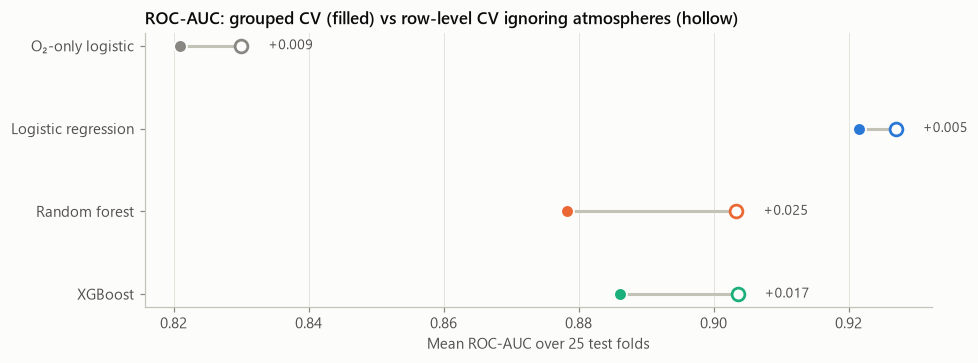

In [9]:
display(leak.round(3))
fig = plots.plot_leakage(leak, "roc_auc", "ROC-AUC")
_ = eda.save(fig, "09_leakage_check")

**Read-out.** Ignoring the groups makes every model look better, and the inflation is largest for the
flexible tree models: +0.017 (XGBoost) and +0.025 (random forest) ROC-AUC and about +0.04 PR-AUC, versus +0.005 for
logistic regression and +0.009 for O₂-only. Row-level CV would have shrunk the gap between logistic regression and the trees — exactly the kind of
misleading conclusion grouped CV protects against. In FLEX each row is a separate droplet test, so the effect is
modest; it would be far larger with repeated measurements of the same burn.

## Summary
| | Result (grouped CV, 25 folds) |
|---|---|
| Best model | Logistic regression: ROC-AUC 0.922 ± 0.050, PR-AUC 0.868 ± 0.087, Brier 0.109 ± 0.034 |
| vs O₂ only | +0.101 ROC-AUC, better in 25/25 splits |
| vs trees | +0.035 to +0.043 ROC-AUC, better in 22–24/25 splits |
| Safe operating point (logreg) | recall 0.898 ± 0.108, precision 0.637 ± 0.130, FPR 0.259 ± 0.148 |
| Leakage if groups ignored | +0.005 to +0.025 ROC-AUC, larger for flexible models |

Next (Phase 8): tune hyperparameters with nested grouped CV, ablate features (interaction term, `p_o2_atm`),
and run the sensitivity variants and stress tests.